# Método da Soma Ponderada e a Fronteira de Pareto
### Seção 9.3.1 — MDO Book · Aplicação ao contexto do TCC (Etapa 6)

---

Este notebook constrói a intuição sobre otimização multiobjetivo em duas camadas:

- **Seções 1–6:** teoria e visualizações genéricas (dados sintéticos)
- **Seções 7–8:** aplicação direta aos 20 pontos Pareto-ótimos do TCC (`6.3_pareto_solucoes.csv`)

Dependências: `numpy`, `pandas`, `matplotlib`, `ipywidgets`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed
from IPython.display import display

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

---
## Seção 1 — Motivação: o conflito entre objetivos

### O problema do TCC

O processo de produção de metanol verde opera sob três métricas de interesse simultâneas:

| Saída | Símbolo | Objetivo | Faixa observada |
|-------|---------|----------|-----------------|
| Consumo de energia | $E_T$ | **Minimizar** | ~6.700 – 84.200 kW |
| Vazão de metanol | $M_{CH_3OH}$ | **Maximizar** | ~4.500 – 12.900 kg/hr |
| Pureza | $x_{CH_3OH}$ | **Restrição** ≥ 0.98 | 0.98 – 1.008 |

O problema é bi-objetivo com restrição:

$$\min_{\mathbf{x} \in S_6} \; [E_T(\mathbf{x}),\; -M_{CH_3OH}(\mathbf{x})]$$
$$\text{sujeito a: } x_{CH_3OH}(\mathbf{x}) \geq 0.98$$

onde $\mathbf{x} = (T_1, RRC_1, BRC_1, RRC_2, BRC_2, RFF)$ são os 6 inputs selecionados na Etapa 3.

### Por que não existe uma solução única óbvia?

Aumentar a produção de metanol geralmente exige condições operacionais mais intensas — maior boil-up nas colunas, maior reciclo — o que eleva o consumo energético. Os dois objetivos **conflitam**: melhorar um tende a piorar o outro. O gráfico abaixo, construído com os 20 pontos Pareto-ótimos encontrados na Etapa 6.3, torna esse conflito visível.

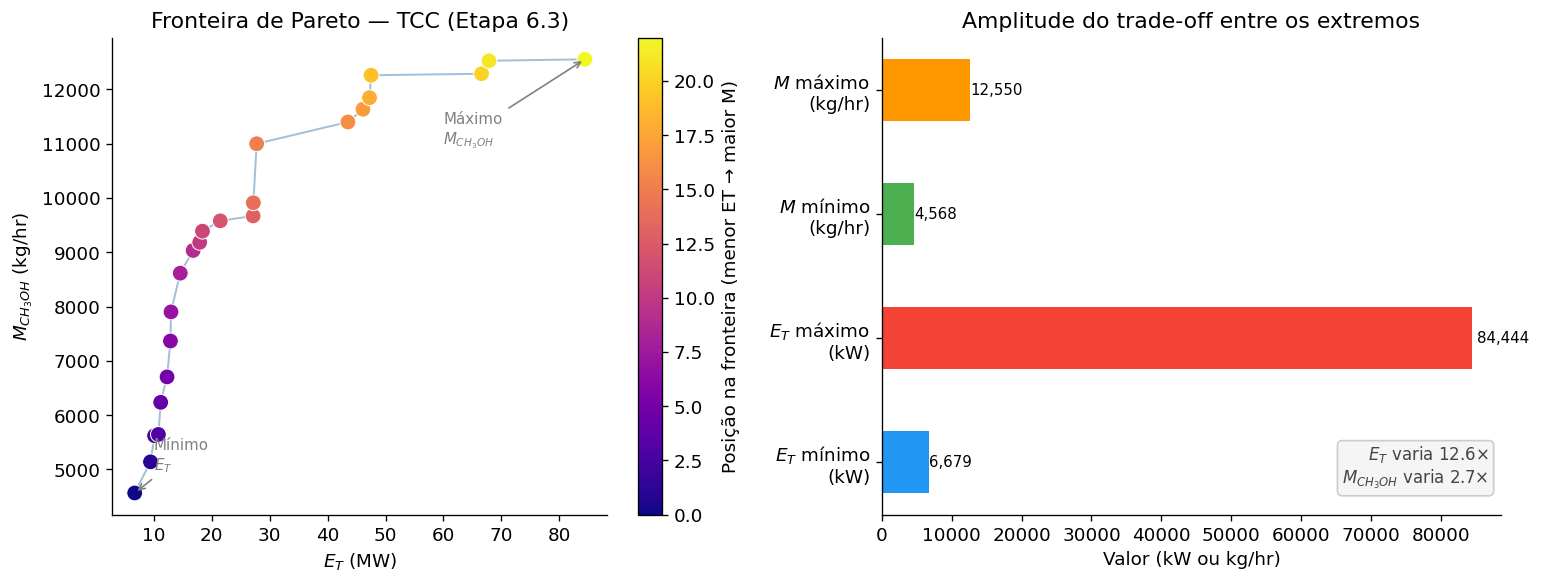


Amplitude do trade-off:
  ET:     6.7 → 84.4 MW  (12.6×)
  M:      4,568 → 12,550 kg/hr  (2.7×)

Reduzir ET de 84→7 MW custa 7,983 kg/hr de produção.


In [2]:
# Carrega os 20 pontos Pareto-ótimos da Etapa 6.3
CSV_PATH = "../6.3/6.3_pareto_solucoes.csv"
df_pareto = pd.read_csv(CSV_PATH)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Painel esquerdo: scatter ET × M com cor = posição na fronteira ---
ax = axes[0]
sc = ax.scatter(
    df_pareto["ET"] / 1e3,
    df_pareto["M_CH3OH"],
    c=range(len(df_pareto)),
    cmap="plasma",
    s=90,
    zorder=3,
    edgecolors="white",
    linewidths=0.6,
)
ax.plot(
    df_pareto["ET"] / 1e3,
    df_pareto["M_CH3OH"],
    color="steelblue",
    linewidth=1.2,
    alpha=0.5,
    zorder=2,
)
plt.colorbar(sc, ax=ax, label="Posição na fronteira (menor ET → maior M)")
ax.set_xlabel("$E_T$ (MW)")
ax.set_ylabel("$M_{CH_3OH}$ (kg/hr)")
ax.set_title("Fronteira de Pareto — TCC (Etapa 6.3)")

# Anota os dois extremos
ax.annotate(
    "Mínimo\n$E_T$",
    xy=(df_pareto["ET"].iloc[0] / 1e3, df_pareto["M_CH3OH"].iloc[0]),
    xytext=(10, 5000),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color="gray"),
    color="gray",
)
ax.annotate(
    "Máximo\n$M_{CH_3OH}$",
    xy=(df_pareto["ET"].iloc[-1] / 1e3, df_pareto["M_CH3OH"].iloc[-1]),
    xytext=(60, 11000),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color="gray"),
    color="gray",
)

# --- Painel direito: amplitude do trade-off em barras ---
ax2 = axes[1]
et_min = df_pareto["ET"].min() / 1e3
et_max = df_pareto["ET"].max() / 1e3
m_min  = df_pareto["M_CH3OH"].min()
m_max  = df_pareto["M_CH3OH"].max()

labels = ["$E_T$ mínimo\n(kW)", "$E_T$ máximo\n(kW)", "$M$ mínimo\n(kg/hr)", "$M$ máximo\n(kg/hr)"]
values = [et_min * 1e3, et_max * 1e3, m_min, m_max]
colors = ["#2196F3", "#F44336", "#4CAF50", "#FF9800"]

bars = ax2.barh([0, 1, 2, 3], values, color=colors, height=0.5)
ax2.set_yticks([0, 1, 2, 3])
ax2.set_yticklabels(labels)
ax2.set_xlabel("Valor (kW ou kg/hr)")
ax2.set_title("Amplitude do trade-off entre os extremos")

for bar, val in zip(bars, values):
    ax2.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
             f"{val:,.0f}", va="center", fontsize=9)

# Destaca os fatores de variação
fator_et = et_max / et_min
fator_m  = m_max / m_min
ax2.text(0.98, 0.05,
         f"$E_T$ varia {fator_et:.1f}×\n$M_{{CH_3OH}}$ varia {fator_m:.1f}×",
         transform=ax2.transAxes, ha="right", va="bottom",
         fontsize=10, color="#444",
         bbox=dict(boxstyle="round,pad=0.3", fc="#f5f5f5", ec="#ccc"))

plt.tight_layout()
plt.savefig("6.0_sec1_conflito_objetivos.png", bbox_inches="tight")
plt.show()

print(f"\nAmplitude do trade-off:")
print(f"  ET:     {et_min:.1f} → {et_max:.1f} MW  ({fator_et:.1f}×)")
print(f"  M:      {m_min:,.0f} → {m_max:,.0f} kg/hr  ({fator_m:.1f}×)")
print(f"\nReduzir ET de {et_max:.0f}→{et_min:.0f} MW custa {(m_max-m_min):,.0f} kg/hr de produção.")

**Leitura do gráfico:**

Cada ponto é um conjunto de condições operacionais $(T_1, RRC_1, BRC_1, RRC_2, BRC_2, RFF)$ que satisfaz $x_{CH_3OH} \geq 0.98$. A curva ascendente da esquerda para a direita confirma o conflito: para produzir mais metanol, o processo consome mais energia. Não existe um ponto que minimize $E_T$ e maximize $M_{CH_3OH}$ simultaneamente.

**Pergunta central da Etapa 6:** qual desses pontos escolher? Para respondê-la, precisamos de um framework formal — que começa com o conceito de dominância de Pareto.

---
## Seção 2 — Fundamentos: Dominância e Fronteira de Pareto

### 2.1 Definições formais

Seja um problema de minimização com $n_f$ objetivos:

$$\min_{\mathbf{x}} \; \mathbf{f}(\mathbf{x}) = [f_1(\mathbf{x}),\, f_2(\mathbf{x}),\, \ldots,\, f_{n_f}(\mathbf{x})]$$

**Dominância de Pareto:** um ponto $\mathbf{a}$ *domina* $\mathbf{b}$ (escrito $\mathbf{a} \prec \mathbf{b}$) se e somente se:

$$f_i(\mathbf{a}) \leq f_i(\mathbf{b}) \quad \forall\, i \in \{1, \ldots, n_f\}$$
$$f_j(\mathbf{a}) < f_j(\mathbf{b}) \quad \text{para ao menos um } j$$

Ou seja: $\mathbf{a}$ domina $\mathbf{b}$ se for **ao menos tão bom em todos os objetivos** e **estritamente melhor em pelo menos um**.

**Conjunto Pareto-ótimo ($\mathcal{P}^*$):** o conjunto de todas as soluções que não são dominadas por nenhuma outra solução viável.

**Fronteira de Pareto:** a imagem de $\mathcal{P}^*$ no espaço de objetivos — a "curva" (ou superfície, em $n_f > 2$) formada pelos valores $\mathbf{f}(\mathbf{x})$ para $\mathbf{x} \in \mathcal{P}^*$.

### 2.2 Intuição geométrica

No espaço de dois objetivos (ambos a minimizar), um ponto $\mathbf{b}$ é dominado se existe algum outro ponto que está simultaneamente mais à **esquerda** (menor $f_1$) e mais **abaixo** (menor $f_2$). Qualquer ponto que não tenha outro ponto nessa posição relativa é Pareto-ótimo.

O algoritmo de identificação é direto: para cada candidato $\mathbf{b}$, verificar se existe algum $\mathbf{a}$ com $f_1(\mathbf{a}) \leq f_1(\mathbf{b})$, $f_2(\mathbf{a}) \leq f_2(\mathbf{b})$, e ao menos uma desigualdade estrita.

In [3]:
def is_dominated(point, candidates):
    """Retorna True se `point` é dominado por algum ponto em `candidates`."""
    f1_p, f2_p = point
    for f1_c, f2_c in candidates:
        if f1_c <= f1_p and f2_c <= f2_p and (f1_c < f1_p or f2_c < f2_p):
            return True
    return False


def pareto_front(points):
    """Retorna máscara booleana: True = não dominado (Pareto-ótimo)."""
    n = len(points)
    mask = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if (points[j, 0] <= points[i, 0] and
                points[j, 1] <= points[i, 1] and
                (points[j, 0] < points[i, 0] or points[j, 1] < points[i, 1])):
                mask[i] = False
                break
    return mask

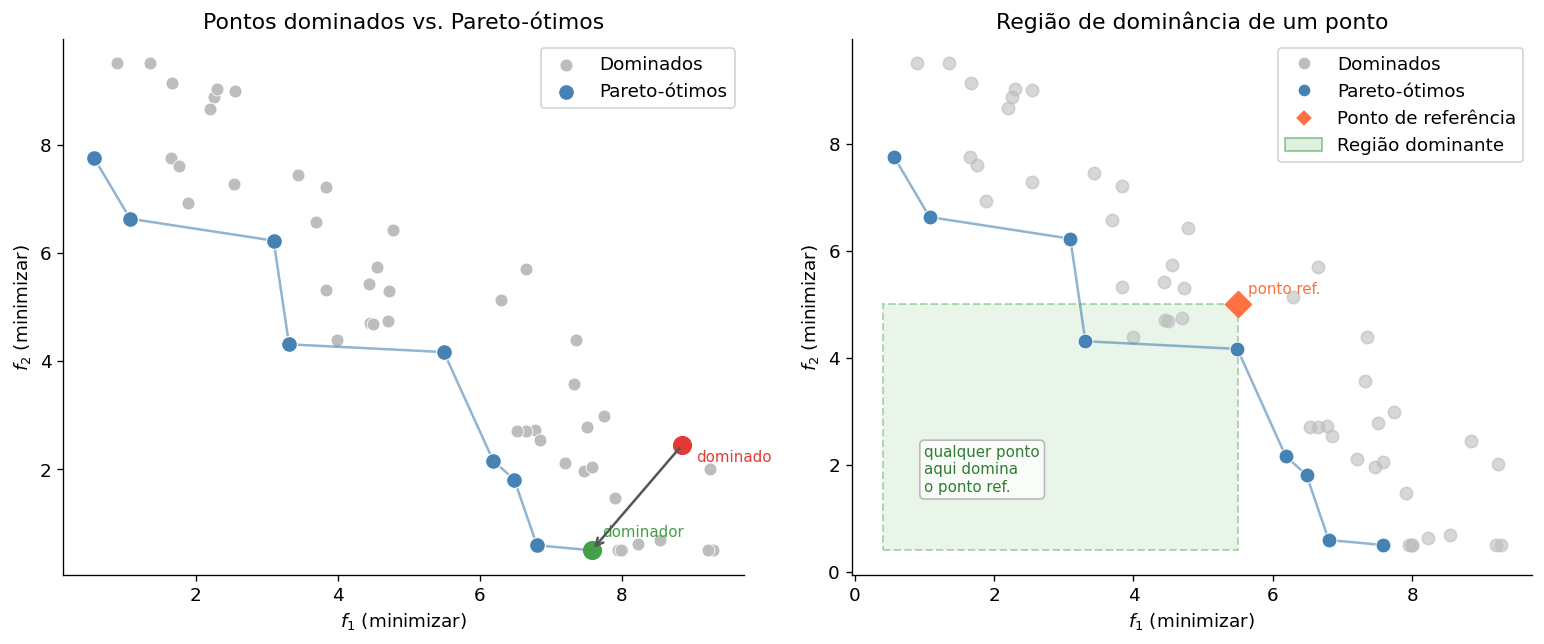

Total de pontos: 55
Pareto-ótimos:   9
Dominados:       46


In [4]:
# Gera ~50 pontos sintéticos no espaço de dois objetivos
rng = np.random.default_rng(42)

# Pontos dispersos com correlação positiva (conflito realista entre f1 e f2)
n_pts = 55
f1_raw = rng.uniform(0.5, 9.5, n_pts)
f2_raw = 10 - f1_raw + rng.normal(0, 1.8, n_pts)
f2_raw = np.clip(f2_raw, 0.5, 9.5)

pontos_sinteticos = np.column_stack([f1_raw, f2_raw])
mask_pareto = pareto_front(pontos_sinteticos)

# Ordena os pontos Pareto por f1 para traçar a curva
pareto_pts = pontos_sinteticos[mask_pareto]
pareto_pts = pareto_pts[np.argsort(pareto_pts[:, 0])]

# --- Figura ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# PAINEL ESQUERDO: scatter com dominados vs. não-dominados
ax = axes[0]

ax.scatter(
    pontos_sinteticos[~mask_pareto, 0],
    pontos_sinteticos[~mask_pareto, 1],
    color="#BDBDBD", s=60, zorder=2, label="Dominados",
    edgecolors="white", linewidths=0.5,
)
ax.scatter(
    pareto_pts[:, 0], pareto_pts[:, 1],
    color="steelblue", s=90, zorder=4, label="Pareto-ótimos",
    edgecolors="white", linewidths=0.7,
)
ax.plot(
    pareto_pts[:, 0], pareto_pts[:, 1],
    color="steelblue", linewidth=1.5, alpha=0.6, zorder=3,
)

# Destaca um ponto dominado e mostra quem o domina
idx_dom = np.where(~mask_pareto)[0][10]
p_dom = pontos_sinteticos[idx_dom]
# Encontra o dominador mais próximo
dists = np.linalg.norm(pareto_pts - p_dom, axis=1)
p_dominator = pareto_pts[np.argmin(dists)]

ax.scatter(*p_dom, color="#E53935", s=110, zorder=5)
ax.scatter(*p_dominator, color="#43A047", s=110, zorder=5)
ax.annotate(
    "", xy=p_dominator, xytext=p_dom,
    arrowprops=dict(arrowstyle="->", color="#555", lw=1.5),
    zorder=6,
)
ax.text(p_dom[0] + 0.2, p_dom[1] - 0.3, "dominado",
        color="#E53935", fontsize=9)
ax.text(p_dominator[0] + 0.15, p_dominator[1] + 0.25, "dominador",
        color="#43A047", fontsize=9)

ax.set_xlabel("$f_1$ (minimizar)")
ax.set_ylabel("$f_2$ (minimizar)")
ax.set_title("Pontos dominados vs. Pareto-ótimos")
ax.legend(loc="upper right", framealpha=0.85)

# PAINEL DIREITO: zoom com retângulo de dominância
ax2 = axes[1]

ax2.scatter(
    pontos_sinteticos[~mask_pareto, 0],
    pontos_sinteticos[~mask_pareto, 1],
    color="#BDBDBD", s=55, zorder=2, alpha=0.6,
)
ax2.scatter(
    pareto_pts[:, 0], pareto_pts[:, 1],
    color="steelblue", s=80, zorder=4,
    edgecolors="white", linewidths=0.6,
)
ax2.plot(
    pareto_pts[:, 0], pareto_pts[:, 1],
    color="steelblue", linewidth=1.5, alpha=0.6, zorder=3,
)

# Ponto de referência arbitrário e seu "quadrante de dominância"
ref = np.array([5.5, 5.0])
ax2.scatter(*ref, color="#FF7043", s=120, zorder=6, marker="D")
ax2.text(ref[0] + 0.15, ref[1] + 0.2, "ponto ref.",
         color="#FF7043", fontsize=9)

# Quadrante inferior-esquerdo: região que dominaria o ponto ref.
rect = plt.Rectangle(
    (0.4, 0.4), ref[0] - 0.4, ref[1] - 0.4,
    linewidth=1.2, edgecolor="#43A047", facecolor="#C8E6C9",
    alpha=0.4, zorder=1, linestyle="--",
)
ax2.add_patch(rect)
ax2.text(1.0, 1.5,
         "qualquer ponto\naqui domina\no ponto ref.",
         color="#2E7D32", fontsize=9,
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#aaa", alpha=0.8))

ax2.set_xlabel("$f_1$ (minimizar)")
ax2.set_ylabel("$f_2$ (minimizar)")
ax2.set_title("Região de dominância de um ponto")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#BDBDBD',
           markersize=8, label='Dominados'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=8, label='Pareto-ótimos'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='#FF7043',
           markersize=8, label='Ponto de referência'),
    mpatches.Patch(facecolor='#C8E6C9', edgecolor='#43A047',
                   label='Região dominante', alpha=0.6),
]
ax2.legend(handles=legend_elements, loc="upper right", framealpha=0.85)

plt.tight_layout()
plt.savefig("6.0_sec2_dominancia_pareto.png", bbox_inches="tight")
plt.show()

print(f"Total de pontos: {n_pts}")
print(f"Pareto-ótimos:   {mask_pareto.sum()}")
print(f"Dominados:       {(~mask_pareto).sum()}")

### 2.3 Leitura dos gráficos

**Painel esquerdo:** cada ponto cinza tem ao menos um outro ponto que é simultaneamente melhor em $f_1$ *e* em $f_2$ — portanto é descartável. Os pontos azuis (Pareto-ótimos) formam a fronteira: nenhum deles pode ser melhorado em qualquer objetivo sem piorar o outro.

**Painel direito:** o retângulo verde marca a "região de dominância" do ponto laranja. Qualquer ponto que caia nessa região (menor $f_1$ *e* menor $f_2$) domina o ponto de referência. Como nenhum ponto Pareto-ótimo cai nesse quadrante para os pontos da fronteira, a fronteira é, por definição, não dominada.

### 2.4 Propriedades importantes

- A fronteira de Pareto é um **conjunto**, não um ponto. Ela contém infinitas soluções (no caso contínuo).
- Todos os pontos da fronteira são igualmente ótimos do ponto de vista matemático. A escolha entre eles é uma **decisão de engenharia** (quanto vale uma unidade adicional de $M_{CH_3OH}$ em termos de custo energético?).
- Em problemas com $n_f > 2$ objetivos, a fronteira é uma superfície de dimensão $n_f - 1$ — difícil de visualizar diretamente.

**Conexão com o TCC:** a Etapa 6.3 já gerou os 20 pontos Pareto-ótimos por varrimento LHS de 50.000 pontos no espaço de $S_6$, filtrados pela restrição $x_{CH_3OH} \geq 0.98$. A Seção 7 deste notebook aplica o conceito de soma ponderada diretamente sobre esses 20 pontos para mostrar como cada configuração de pesos seleciona um ponto diferente da fronteira.

---
*Próxima seção: o Método da Soma Ponderada — como escalarizar o problema bi-objetivo em um único objetivo paramétrico.*

---
## Seção 3 — O Método da Soma Ponderada (§9.3.1)

### 3.1 Formulação

A abordagem mais simples para transformar um problema multiobjetivo em escalar é a **soma ponderada**. Dado um problema de minimização bi-objetivo $(f_1, f_2)$, define-se um escalar agregado:

$$\bar{f}(\mathbf{x}) = w \cdot \tilde{f}_1(\mathbf{x}) + (1-w) \cdot \tilde{f}_2(\mathbf{x}), \quad w \in [0,1]$$

onde $\tilde{f}_i$ indica a versão **normalizada** de $f_i$ (para que ambos os objetivos tenham a mesma escala).

**Para o TCC:**

$$\tilde{f}_1 = \frac{E_T - E_T^{\min}}{E_T^{\max} - E_T^{\min}}, \qquad \tilde{f}_2 = -\frac{M_{CH_3OH} - M_{\min}}{M_{\max} - M_{\min}}$$

O sinal negativo em $\tilde{f}_2$ converte a maximização de $M_{CH_3OH}$ em minimização: $\max M \equiv \min (-M)$.

O parâmetro $w$ controla o **compromisso**:
- $w = 1$: apenas $E_T$ importa → ponto de mínima energia
- $w = 0$: apenas $M_{CH_3OH}$ importa → ponto de máxima produção
- $w \in (0,1)$: compromisso proporcional entre os dois objetivos

### 3.2 Interpretação geométrica

No espaço de objetivos $(\tilde{f}_1, \tilde{f}_2)$, o escalar $\bar{f} = c$ define uma **reta de nível**:

$$\tilde{f}_2 = \frac{c}{1-w} - \frac{w}{1-w} \cdot \tilde{f}_1$$

com inclinação $-\dfrac{w}{1-w}$.

Minimizar $\bar{f}$ equivale a deslocar essa reta em direção à origem (valores menores de $c$) até que ela seja **tangente** à fronteira de Pareto. O ponto de tangência é a solução ótima para aquele valor de $w$.

**Consequência:** cada $w$ gera uma reta com inclinação diferente, que toca a fronteira em um ponto diferente. Varrendo $w$ de 0 a 1, percorre-se (parte da) fronteira de Pareto.

O gráfico abaixo ilustra três configurações de peso em uma fronteira convexa sintética.

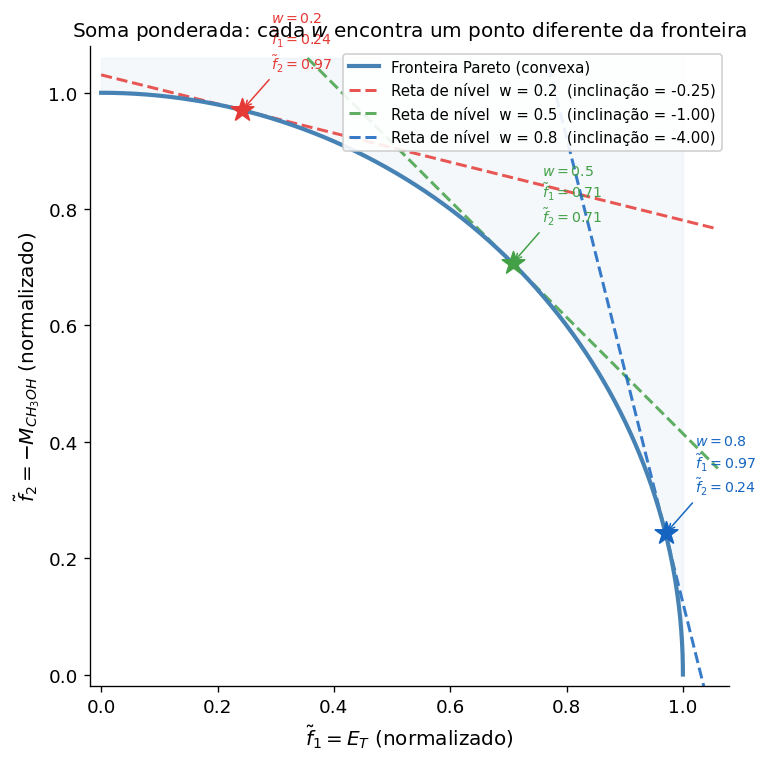

Pontos ótimos por peso:
  w = 0.2  →  f̃₁ = 0.243,  f̃₂ = 0.970,  inclinação = -0.250
  w = 0.5  →  f̃₁ = 0.707,  f̃₂ = 0.707,  inclinação = -1.000
  w = 0.8  →  f̃₁ = 0.970,  f̃₂ = 0.243,  inclinação = -4.000


In [5]:
def pareto_circle_front(n=400):
    """Fronteira Pareto convexa analítica: quarto de círculo f1²+f2²=1, f1,f2 ≥ 0."""
    t = np.linspace(0, np.pi / 2, n)
    return np.sin(t), np.cos(t)


def optimal_on_circle(w):
    """Ponto ótimo na fronteira circular para peso w. Minimiza w*f1+(1-w)*f2."""
    norm = np.sqrt(w**2 + (1 - w)**2)
    return w / norm, (1 - w) / norm


f1_fc, f2_fc = pareto_circle_front()

weights_demo = [0.2, 0.5, 0.8]
colors_demo  = ['#E53935', '#43A047', '#1565C0']

fig, ax = plt.subplots(figsize=(8, 6.5))

ax.plot(f1_fc, f2_fc, color='steelblue', lw=2.5, label='Fronteira Pareto (convexa)', zorder=3)
ax.fill_between(f1_fc, f2_fc, 1.06, alpha=0.05, color='steelblue')

f1_grid = np.linspace(0, 1.06, 300)

for w, cor in zip(weights_demo, colors_demo):
    f1_opt, f2_opt = optimal_on_circle(w)
    c_opt = w * f1_opt + (1 - w) * f2_opt

    # Reta de nível: f2 = c/(1-w) - w/(1-w)*f1
    f2_lvl = c_opt / (1 - w) - (w / (1 - w)) * f1_grid
    mask = (f2_lvl >= -0.05) & (f2_lvl <= 1.06) & (f1_grid >= 0)

    slope = -w / (1 - w)
    ax.plot(f1_grid[mask], f2_lvl[mask], '--', color=cor, lw=1.8, alpha=0.85,
            label=f'Reta de nível  w = {w}  (inclinação = {slope:.2f})')
    ax.scatter(f1_opt, f2_opt, color=cor, s=200, zorder=5, marker='*')
    ax.annotate(
        f'$w={w}$\n$\\tilde{{f}}_1={f1_opt:.2f}$\n$\\tilde{{f}}_2={f2_opt:.2f}$',
        xy=(f1_opt, f2_opt),
        xytext=(f1_opt + 0.05, f2_opt + 0.07),
        fontsize=8.5, color=cor,
        arrowprops=dict(arrowstyle='->', color=cor, lw=0.9),
    )

ax.set_xlim(-0.02, 1.08)
ax.set_ylim(-0.02, 1.08)
ax.set_xlabel('$\\tilde{f}_1 = E_T$ (normalizado)', fontsize=12)
ax.set_ylabel('$\\tilde{f}_2 = -M_{CH_3OH}$ (normalizado)', fontsize=12)
ax.set_title('Soma ponderada: cada $w$ encontra um ponto diferente da fronteira', fontsize=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('6.0_sec3_soma_ponderada.png', bbox_inches='tight')
plt.show()

print("Pontos ótimos por peso:")
for w in weights_demo:
    f1_opt, f2_opt = optimal_on_circle(w)
    print(f"  w = {w:.1f}  →  f̃₁ = {f1_opt:.3f},  f̃₂ = {f2_opt:.3f},  inclinação = {-w/(1-w):.3f}")

---
## Seção 4 — Widget 1: Geometria do peso (espaço sintético)

O gráfico anterior mostrou três configurações fixas. O widget abaixo permite explorar continuamente como a escolha de $w$ desloca o ponto ótimo ao longo da fronteira.

**Como usar:**
- Mova o slider de $w$ e observe como a reta de nível gira e o ponto ótimo (estrela vermelha) migra
- $w \to 0$: reta quase horizontal → prioriza $\tilde{f}_2$ (máxima produção de $M_{CH_3OH}$)
- $w \to 1$: reta quase vertical → prioriza $\tilde{f}_1$ (mínimo consumo de $E_T$)
- $w = 0.5$: pesos iguais → ponto médio da fronteira (para fronteira simétrica como o círculo)

**Observação:** a inclinação da reta é $-w/(1-w)$. Dobrar $w$ de 0.25 para 0.50 triplica a inclinação em módulo (de −0.33 para −1.00). Isso é um primeiro indício de por que espaçar pesos uniformemente não distribui pontos uniformemente na fronteira — o que a Seção 5 explorará em detalhe.

In [6]:
def _plot_sec4(w):
    f1_fc, f2_fc = pareto_circle_front()
    f1_opt, f2_opt = optimal_on_circle(w)
    c_opt = w * f1_opt + (1 - w) * f2_opt
    inclinacao = -w / (1 - w)
    prio_et = int(round(w * 100))
    prio_m = 100 - prio_et

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(f1_fc, f2_fc, color='steelblue', lw=2.5, label='Fronteira Pareto (convexa)', zorder=3)
    ax.fill_between(f1_fc, f2_fc, 1.06, alpha=0.05, color='steelblue')

    # Reta de nível ótima
    f1_grid = np.linspace(0, 1.06, 300)
    f2_lvl = c_opt / (1 - w) - (w / (1 - w)) * f1_grid
    mask = (f2_lvl >= -0.05) & (f2_lvl <= 1.08)
    ax.plot(f1_grid[mask], f2_lvl[mask], '--', color='#E53935', lw=2.0,
            alpha=0.9, label='Reta de nível ótima', zorder=4)

    # Linhas de referência até os eixos (tracejado leve)
    ax.plot([0, f1_opt, f1_opt], [f2_opt, f2_opt, 0],
            ':', color='#aaa', lw=1.0, zorder=2)

    # Ponto ótimo
    ax.scatter(f1_opt, f2_opt, color='#E53935', s=320, zorder=6,
               marker='*', label='Ponto ótimo')

    ax.set_xlim(-0.02, 1.08)
    ax.set_ylim(-0.02, 1.08)
    ax.set_xlabel('$\\tilde{f}_1 = E_T$ (normalizado)', fontsize=11)
    ax.set_ylabel('$\\tilde{f}_2 = -M_{CH_3OH}$ (normalizado)', fontsize=11)
    ax.set_title(
        f'$w = {w:.2f}$  →  inclinação $= {inclinacao:.3f}$  →  '
        f'prioriza {prio_et}% energia / {prio_m}% produção',
        fontsize=11,
    )
    ax.set_aspect('equal')
    ax.legend(loc='upper right', fontsize=10, framealpha=0.9)

    ax.text(
        0.03, 0.04,
        f'Ponto ótimo:  $\\tilde{{f}}_1 = {f1_opt:.3f}$,   $\\tilde{{f}}_2 = {f2_opt:.3f}$',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round,pad=0.4', fc='#fff9c4', ec='#f9a825', alpha=0.95),
    )

    plt.tight_layout()
    plt.show()


w_slider = widgets.FloatSlider(
    min=0.01, max=0.99, step=0.01, value=0.50,
    description='$w$:',
    continuous_update=False,
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='520px'),
)

interact(_plot_sec4, w=w_slider)

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='$w$:', layout=Layout(width=…

<function __main__._plot_sec4(w)>

---
## Seção 5 — Widget 2: Espaçamento não-uniforme

A Seção 4 mostrou que cada $w$ mapeia para um único ponto na fronteira. Uma estratégia natural seria varrer $N$ pesos uniformemente espaçados em $[0, 1]$ para obter $N$ soluções Pareto diversas. O widget abaixo revela o problema: **intervalos iguais em $w$ não produzem intervalos iguais na fronteira**.

**Como usar:**
- Mova o slider de $N$ e observe a distribuição dos pontos marcados na fronteira circular
- Com poucos pontos ($N$ pequeno), o efeito é visível na posição das estrelas
- Com muitos pontos ($N$ grande), as estrelas revelam aglomeração nas extremidades e escassez no centro
- O texto dinâmico mostra a distância média e o desvio-padrão entre pontos consecutivos na fronteira

**Por que isso acontece?** A inclinação da reta de nível é $-w/(1-w)$, função não-linear de $w$. Próximo a $w=0$ e $w=1$, pequenas variações de $w$ geram grandes variações de inclinação, concentrando pontos. No interior $w \approx 0.5$, a função é mais estável e os pontos ficam mais esparsos — o inverso do que seria desejável para uma cobertura uniforme.

Esse fenômeno é a **não-uniformidade** citada em §9.3.1 como primeira limitação da soma ponderada.

In [7]:
def _plot_sec5(N):
    pesos = np.linspace(0, 1, N)
    # Para w=0 e w=1 exatos, optimal_on_circle retorna os extremos do arco
    pts = np.array([optimal_on_circle(w) for w in pesos])

    # Distâncias geodésicas no arco (ângulo entre pontos consecutivos × raio=1)
    angulos = np.arctan2(pts[:, 1], pts[:, 0])  # ângulos no 1º quadrante
    dists_arco = np.abs(np.diff(angulos))        # diferença de ângulo ≈ comprimento de arco
    dist_media = dists_arco.mean()
    dist_std   = dists_arco.std()

    f1_fc, f2_fc = pareto_circle_front()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    # --- Painel esquerdo: posição dos pontos na fronteira ---
    ax = axes[0]
    ax.plot(f1_fc, f2_fc, color='steelblue', lw=2.5, zorder=2, label='Fronteira Pareto')
    ax.scatter(pts[:, 0], pts[:, 1], color='#E53935', s=80, zorder=4,
               marker='*', label=f'{N} pontos (pesos uniformes)')
    ax.set_xlim(-0.02, 1.08)
    ax.set_ylim(-0.02, 1.08)
    ax.set_aspect('equal')
    ax.set_xlabel('$\\tilde{f}_1$')
    ax.set_ylabel('$\\tilde{f}_2$')
    ax.set_title(f'$N = {N}$ pontos gerados por pesos uniformes $w \\in [0,1]$')
    ax.legend(loc='upper right', fontsize=9)

    # Anotação: região central vs. extremos
    n_terco = max(1, N // 3)
    d_ext = dists_arco[:n_terco].mean() if n_terco > 0 else 0
    d_ctr = dists_arco[n_terco: 2*n_terco].mean() if n_terco > 0 else 0
    if d_ctr > 0:
        razao = d_ext / d_ctr
        ax.text(0.03, 0.07,
                f'Extremos: espaçamento médio = {d_ext:.3f} rad\n'
                f'Centro:   espaçamento médio = {d_ctr:.3f} rad\n'
                f'Razão extremo/centro = {razao:.2f}×',
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.4', fc='#fff9c4', ec='#f9a825', alpha=0.95))

    # --- Painel direito: histograma de distâncias entre pontos consecutivos ---
    ax2 = axes[1]
    if N > 2:
        ax2.bar(range(len(dists_arco)), dists_arco, color='steelblue', alpha=0.75, width=0.8)
        ax2.axhline(dist_media, color='#E53935', lw=1.8, linestyle='--',
                    label=f'Média = {dist_media:.4f} rad')
        ax2.axhline(dist_media + dist_std, color='#FF9800', lw=1.2, linestyle=':',
                    label=f'±1σ = {dist_std:.4f} rad')
        ax2.axhline(dist_media - dist_std, color='#FF9800', lw=1.2, linestyle=':')
        ax2.set_xlabel('Par consecutivo $i$')
        ax2.set_ylabel('Distância no arco (rad)')
        ax2.set_title('Distância entre pontos consecutivos na fronteira')
        ax2.legend(fontsize=9)
        ax2.text(0.98, 0.95,
                 f'CV = {dist_std/dist_media:.3f}' if dist_media > 0 else '',
                 transform=ax2.transAxes, ha='right', va='top', fontsize=10,
                 bbox=dict(boxstyle='round,pad=0.3', fc='#f5f5f5', ec='#ccc'))
    else:
        ax2.text(0.5, 0.5, 'N muito pequeno\npara calcular distâncias',
                 ha='center', va='center', transform=ax2.transAxes, fontsize=11)

    plt.tight_layout()
    plt.show()

    print(f"N = {N} pontos  |  dist. média no arco = {dist_media:.4f} rad  |  "
          f"desvio-padrão = {dist_std:.4f} rad  |  CV = {dist_std/dist_media:.3f}" if dist_media > 0 else "")


n_slider = widgets.IntSlider(
    min=3, max=60, step=1, value=10,
    description='$N$ pontos:',
    continuous_update=False,
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='520px'),
)

interact(_plot_sec5, N=n_slider)

interactive(children=(IntSlider(value=10, continuous_update=False, description='$N$ pontos:', layout=Layout(wi…

<function __main__._plot_sec5(N)>

---
## Seção 6 — Limitação: Regiões Não-Convexas

### 6.1 O problema geométrico

A interpretação geométrica da soma ponderada (reta de nível tangente à fronteira) funciona corretamente apenas quando a fronteira é **convexa**. Para entender por quê, considere a equação da reta de nível:

$$\tilde{f}_2 = \frac{c}{1-w} - \frac{w}{1-w}\,\tilde{f}_1$$

Minimizar $\bar{f}$ significa deslocar essa reta em direção à origem. Em uma fronteira convexa, esse deslocamento sempre atinge um único ponto de tangência — a solução ótima. Varrendo $w \in [0,1]$, a reta varre toda a fronteira.

Em uma fronteira **côncava** (ou não-convexa), a reta de nível pode "saltar" sobre uma região inteira: ao ser deslocada em direção à origem, ela passa diretamente de um trecho convexo a outro, sem nunca ser tangente aos pontos côncavos intermediários. Independentemente do valor de $w$ escolhido, esses pontos jamais serão soluções ótimas da soma ponderada.

### 6.2 Consequência prática

Pontos na região côncava são **Pareto-ótimos** (nenhum outro ponto os domina), mas a soma ponderada é incapaz de encontrá-los. O método perde soluções válidas e potencialmente valiosas do espaço de design.

### 6.3 Relevância para o TCC

O LHS de 50.000 pontos usado na Etapa 6.3 não sofre dessa limitação: ele avalia o surrogate em uma grade quasi-aleatória densa e filtra os não-dominados independentemente da forma da fronteira. Se a fronteira real do processo fosse côncava (algo que não é possível garantir a priori com dados discretos), a soma ponderada perderia soluções — o LHS as encontraria de qualquer forma.

O gráfico abaixo demonstra o fenômeno nos dois casos.

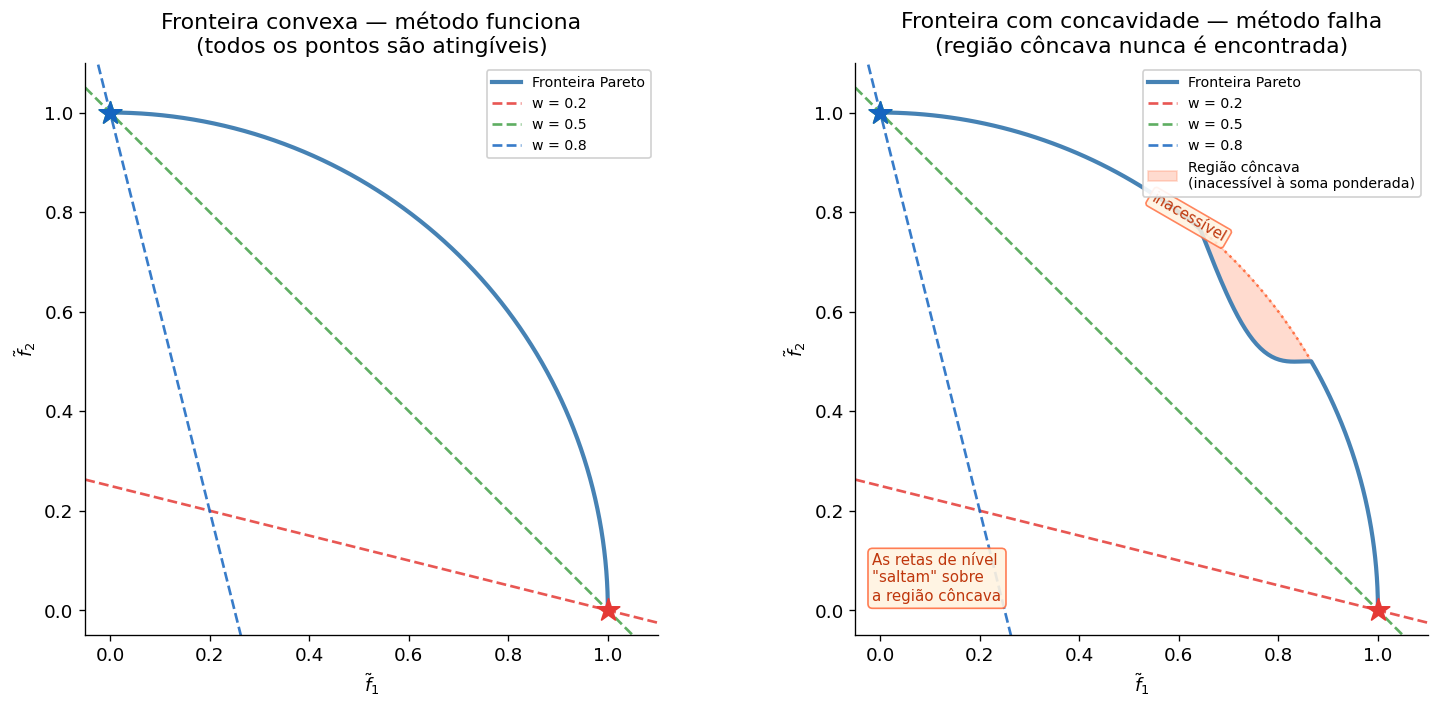

Seção 6 — conclusão:
  Fronteira convexa  → soma ponderada encontra todos os pontos Pareto-ótimos.
  Fronteira côncava  → pontos na região côncava são PERDIDOS independentemente de w.
  LHS (Etapa 6.3)    → não tem essa limitação; varrimento denso cobre qualquer forma.


In [8]:
# --- Fronteiras sintéticas para ilustrar convexidade vs. concavidade ---

def _convex_front(n=300):
    """Quarto de círculo — fronteira puramente convexa."""
    t = np.linspace(0, np.pi / 2, n)
    return np.sin(t), np.cos(t)


def _concave_front(n=300):
    """Fronteira com concavidade no trecho central.
    Construída como dois arcos convexos ligados por uma depressão côncava."""
    # Segmento 1: arco de 0 a ~40° (convexo)
    t1 = np.linspace(0, np.radians(40), 80)
    x1 = np.sin(t1)
    y1 = np.cos(t1)

    # Segmento côncavo: parábola "afundada" para dentro
    x_mid = np.linspace(np.sin(np.radians(40)), np.sin(np.radians(60)), 60)
    # curva convexa seria y = sqrt(1-x²); côncava = reduzida
    y_conv = np.sqrt(np.clip(1 - x_mid**2, 0, 1))
    sag = 0.12 * np.sin(np.pi * (x_mid - x_mid[0]) / (x_mid[-1] - x_mid[0]))
    y_mid = y_conv - sag

    # Segmento 2: arco de ~60° a 90° (convexo)
    t2 = np.linspace(np.radians(60), np.pi / 2, 80)
    x2 = np.sin(t2)
    y2 = np.cos(t2)

    xf = np.concatenate([x1, x_mid, x2])
    yf = np.concatenate([y1, y_mid, y2])
    return xf, yf


def _tangent_line_on_front(xf, yf, w, f1_grid):
    """Para cada w, encontra o ponto da fronteira discreta que minimiza w*f1+(1-w)*f2,
    e retorna o ponto ótimo e os valores da reta de nível correspondente."""
    scores = w * xf + (1 - w) * yf
    idx = np.argmin(scores)
    c_opt = scores[idx]
    f2_lvl = c_opt / (1 - w) - (w / (1 - w)) * f1_grid
    return xf[idx], yf[idx], f2_lvl


def _draw_panel(ax, xf, yf, titulo, highlight_concave=False):
    """Desenha a fronteira + 3 retas de nível em um eixo."""
    f1_grid = np.linspace(-0.05, 1.1, 400)
    weights = [0.2, 0.5, 0.8]
    colors  = ['#E53935', '#43A047', '#1565C0']

    ax.plot(xf, yf, color='steelblue', lw=2.5, zorder=3, label='Fronteira Pareto')

    for w, cor in zip(weights, colors):
        fx_opt, fy_opt, f2_lvl = _tangent_line_on_front(xf, yf, w, f1_grid)
        mask = (f2_lvl >= -0.08) & (f2_lvl <= 1.1)
        ax.plot(f1_grid[mask], f2_lvl[mask], '--', color=cor, lw=1.6, alpha=0.85,
                label=f'w = {w}')
        ax.scatter(fx_opt, fy_opt, color=cor, s=200, zorder=5, marker='*')

    if highlight_concave:
        # Sombreia a região côncava inacessível
        x_conc = np.linspace(np.sin(np.radians(40)), np.sin(np.radians(60)), 60)
        y_conv_ref = np.sqrt(np.clip(1 - x_conc**2, 0, 1))
        sag = 0.12 * np.sin(np.pi * (x_conc - x_conc[0]) / (x_conc[-1] - x_conc[0]))
        y_conc = y_conv_ref - sag
        ax.fill_between(x_conc, y_conc, y_conv_ref, alpha=0.25, color='#FF7043',
                        label='Região côncava\n(inacessível à soma ponderada)')
        ax.plot(x_conc, y_conv_ref, ':', color='#FF7043', lw=1.5)
        ax.text(0.54, 0.74, 'inacessível', color='#BF360C', fontsize=9,
                rotation=-30,
                bbox=dict(boxstyle='round,pad=0.2', fc='#FFF3E0', ec='#FF7043', alpha=0.85))

    ax.set_xlim(-0.05, 1.1)
    ax.set_ylim(-0.05, 1.1)
    ax.set_aspect('equal')
    ax.set_xlabel('$\\tilde{f}_1$')
    ax.set_ylabel('$\\tilde{f}_2$')
    ax.set_title(titulo)
    ax.legend(loc='upper right', fontsize=8.5, framealpha=0.9)


xf_cvx, yf_cvx = _convex_front()
xf_ccv, yf_ccv = _concave_front()

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

_draw_panel(axes[0], xf_cvx, yf_cvx,
            'Fronteira convexa — método funciona\n(todos os pontos são atingíveis)',
            highlight_concave=False)

_draw_panel(axes[1], xf_ccv, yf_ccv,
            'Fronteira com concavidade — método falha\n(região côncava nunca é encontrada)',
            highlight_concave=True)

# Nota explicativa no painel direito
axes[1].text(0.03, 0.06,
             'As retas de nível\n"saltam" sobre\na região côncava',
             transform=axes[1].transAxes, fontsize=9, color='#BF360C',
             bbox=dict(boxstyle='round,pad=0.3', fc='#FFF3E0', ec='#FF7043', alpha=0.9))

plt.tight_layout()
plt.savefig('6.0_sec6_nao_convexidade.png', bbox_inches='tight')
plt.show()

print("Seção 6 — conclusão:")
print("  Fronteira convexa  → soma ponderada encontra todos os pontos Pareto-ótimos.")
print("  Fronteira côncava  → pontos na região côncava são PERDIDOS independentemente de w.")
print("  LHS (Etapa 6.3)    → não tem essa limitação; varrimento denso cobre qualquer forma.")

---
## Seção 7 — Aplicação ao TCC: fronteira real e seleção por peso

As seções anteriores usaram dados sintéticos para construir a intuição. Esta seção ancora o método nos 23 pontos Pareto-ótimos encontrados na Etapa 6.3 (`6.3_pareto_solucoes.csv`).

**Normalização:** $E_T$ e $M_{CH_3OH}$ são normalizados para $[0,1]$ sobre o range dos 23 pontos para que o peso $w$ tenha escala consistente:

$$\tilde{f}_1 = \frac{E_T - E_T^{\min}}{E_T^{\max} - E_T^{\min}}, \qquad \tilde{f}_2 = -\frac{M - M^{\min}}{M^{\max} - M^{\min}}$$

$$\bar{f} = w\,\tilde{f}_1 + (1-w)\,\tilde{f}_2 \quad \Rightarrow \quad \mathbf{x}^*(w) = \arg\min_{i \in \mathcal{P}} \bar{f}(\mathbf{x}_i)$$

O widget abaixo permite explorar como a escolha de $w$ seleciona diferentes pontos da fronteira real e como os inputs operacionais associados variam.

**Painel esquerdo:** fronteira Pareto real no espaço $E_T \times M_{CH_3OH}$; ponto selecionado em vermelho; reta de nível correspondente a $\bar{f} = \bar{f}^*$.

**Painel direito:** valores normalizados dos 6 inputs do ponto selecionado, sobrepostos ao range do espaço de design como referência de escala.

In [9]:
# --- Carrega os pontos Pareto reais da Etapa 6.3 ---
CSV_PATH_PARETO = "../6.3/6.3_pareto_solucoes.csv"
df_p = pd.read_csv(CSV_PATH_PARETO)

ET_vals = df_p["ET"].values
M_vals  = df_p["M_CH3OH"].values

ET_min_p, ET_max_p = ET_vals.min(), ET_vals.max()
M_min_p,  M_max_p  = M_vals.min(),  M_vals.max()

ET_norm_p = (ET_vals - ET_min_p) / (ET_max_p - ET_min_p)
M_norm_p  = (M_vals  - M_min_p)  / (M_max_p  - M_min_p)

# Ranges do espaço de design (CLAUDE.md)
INPUT_RANGES = {
    "T1":   (200.0, 300.0),
    "RRC1": (1.0,   10.0),
    "BRC1": (0.5,   10.0),
    "RRC2": (1.0,   10.0),
    "BRC2": (0.5,   10.0),
    "RFF":  (0.01,  0.25),
}
INPUT_LABELS = ["$T_1$ (°C)", "$RRC_1$", "$BRC_1$", "$RRC_2$", "$BRC_2$", "$RFF$"]
INPUT_KEYS   = ["T1", "RRC1", "BRC1", "RRC2", "BRC2", "RFF"]

# Medianas para classificação alto/baixo
BRC1_med = np.median(df_p["BRC1"].values)
RFF_med  = np.median(df_p["RFF"].values)


def _select_idx(w):
    """Índice do ponto Pareto que minimiza w*f̃1 + (1-w)*f̃2."""
    w_s = np.clip(w, 1e-6, 1 - 1e-6)
    scores = w_s * ET_norm_p - (1 - w_s) * M_norm_p
    return int(np.argmin(scores))


def _plot_sec7(w):
    idx = _select_idx(w)
    row = df_p.iloc[idx]

    ET_sel  = ET_vals[idx]
    M_sel   = M_vals[idx]
    x_sel   = row["x_CH3OH"]
    BRC1_sel = row["BRC1"]
    RFF_sel  = row["RFF"]

    w_s = np.clip(w, 1e-6, 1 - 1e-6)
    c_opt = w_s * ET_norm_p[idx] - (1 - w_s) * M_norm_p[idx]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    # ── Painel esquerdo: scatter ET × M + ponto selecionado + reta de nível ──
    ax = axes[0]
    ax.scatter(ET_vals / 1e3, M_vals, color="steelblue", s=70, zorder=3,
               label="Pontos Pareto", edgecolors="white", linewidths=0.6)
    ax.plot(ET_vals / 1e3, M_vals, color="steelblue", alpha=0.3, lw=1.0, zorder=2)
    ax.scatter(ET_sel / 1e3, M_sel, color="#E53935", s=280, zorder=6,
               marker="*", label=f"Selecionado (w = {w:.2f})")

    # Reta de nível: M_norm = (w*ET_norm - c) / (1-w)
    ET_grid = np.linspace(ET_min_p * 0.90, ET_max_p * 1.10, 400)
    ET_norm_grid = (ET_grid - ET_min_p) / (ET_max_p - ET_min_p)
    M_norm_line = (w_s * ET_norm_grid - c_opt) / (1 - w_s)
    M_line = M_min_p + M_norm_line * (M_max_p - M_min_p)
    mask_lvl = (M_norm_line >= -0.15) & (M_norm_line <= 1.15)
    ax.plot(ET_grid[mask_lvl] / 1e3, M_line[mask_lvl],
            "--", color="#E53935", lw=1.8, alpha=0.85, label="Reta de nível", zorder=4)

    ax.set_xlabel("$E_T$ (MW)")
    ax.set_ylabel("$M_{CH_3OH}$ (kg/hr)")
    ax.set_title(f"Fronteira de Pareto — TCC | $w = {w:.2f}$")
    ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
    ax.text(0.03, 0.97,
            f"ET = {ET_sel/1e3:.1f} MW\nM = {M_sel:,.0f} kg/hr\n$x_{{CH_3OH}}$ = {x_sel:.4f}",
            transform=ax.transAxes, fontsize=9.5, va="top",
            bbox=dict(boxstyle="round,pad=0.4", fc="#fff9c4", ec="#f9a825", alpha=0.95))

    # ── Painel direito: barras horizontais dos 6 inputs ──
    ax2 = axes[1]
    y_pos = np.arange(len(INPUT_KEYS))

    for i, key in enumerate(INPUT_KEYS):
        val = row[key]
        lo, hi = INPUT_RANGES[key]
        val_norm_i = (val - lo) / (hi - lo)

        # Fundo: range completo
        ax2.barh(i, 1.0, color="#E0E0E0", height=0.5, left=0, zorder=1)
        # Valor atual
        ax2.barh(i, val_norm_i, color="steelblue", height=0.5, left=0, alpha=0.85, zorder=2)
        # Valor numérico
        x_txt = val_norm_i + 0.02
        ax2.text(x_txt, i, f"{val:.3g}", va="center", ha="left", fontsize=9)

    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(INPUT_LABELS, fontsize=10)
    ax2.set_xlim(0, 1.35)
    ax2.set_xlabel("Posição normalizada no espaço de design [0 = mín, 1 = máx]")
    ax2.set_title("Inputs do ponto selecionado\n(cinza = range completo; azul = valor atual)")
    ax2.axvline(0.5, color="#aaa", lw=0.8, linestyle=":", zorder=0)

    brc1_nivel = "alto" if BRC1_sel > BRC1_med else "baixo"
    rff_nivel  = "alto" if RFF_sel  > RFF_med  else "baixo"
    ax2.text(0.98, 0.04,
             f"$BRC_1$ = {BRC1_sel:.3f} ({brc1_nivel})\n$RFF$ = {RFF_sel:.4f} ({rff_nivel})",
             transform=ax2.transAxes, ha="right", va="bottom", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.4", fc="#fff9c4", ec="#f9a825", alpha=0.95))

    fig.suptitle(
        f"ET = {ET_sel/1e3:.1f} MW  |  M = {M_sel:,.0f} kg/hr  |  "
        f"$BRC_1$ = {BRC1_sel:.2f} ({brc1_nivel})  |  RFF = {RFF_sel:.4f} ({rff_nivel})",
        fontsize=10, y=0.01,
    )
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()


w_slider_7 = widgets.FloatSlider(
    min=0.0, max=1.0, step=0.01, value=0.50,
    description="$w$ (energia):",
    continuous_update=False,
    style={"description_width": "initial"},
    layout=widgets.Layout(width="560px"),
)

interact(_plot_sec7, w=w_slider_7)

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='$w$ (energia):', layout=Lay…

<function __main__._plot_sec7(w)>

### 7.1 Análise da fronteira do TCC

**A fronteira parece convexa?**
Observando o scatter $E_T \times M_{CH_3OH}$ gerado pelo widget, os 23 pontos formam uma curva monotonicamente crescente e com curvatura positiva — característica de uma fronteira convexa. Não há indicação visual de concavidade. Para a fronteira do TCC, a soma ponderada teoricamente alcançaria todos os pontos; para verificar com rigor seria necessário testar se todos os 23 pontos são soluções ótimas para algum $w \in [0,1]$.

**Os pontos estão bem distribuídos?**
A distribuição dos 23 pontos ao longo da fronteira não é uniforme em espaço de objetivos: há concentração na região de baixo $E_T$ / baixo $M$ e maior dispersão no trecho de alta produção. Isso é esperado — o LHS de 50k pontos amostra o espaço de inputs uniformemente, não o espaço de objetivos. A fronteira em si é resultado da geometria do processo, não de uma estratégia de distribuição uniforme no espaço de objetivos.

**A soma ponderada captaria todas as 23 soluções?**
Em princípio sim, se a fronteira for convexa. Na prática, como o método precisa de um otimizador para cada $w$ (no caso contínuo), e não de uma varredura de 50k pontos, haveria risco de omitir soluções em trechos da fronteira com curvatura alta — onde variações pequenas de $w$ geram pulos grandes no espaço de objetivos. O varrimento denso por LHS elimina esse risco ao custo de avaliações adicionais do surrogate (triviais em termos computacionais).

---
## Seção 8 — Síntese: Soma Ponderada vs. LHS do TCC

### 8.1 Tabela comparativa

| Critério | Soma ponderada | LHS 50k pontos (TCC) |
|----------|----------------|----------------------|
| Complexidade de implementação | Baixa | Baixa (com surrogate barato) |
| Cobertura de fronteiras não-convexas | Não | Sim |
| Uniformidade dos pontos gerados | Não garantida | Quasi-uniforme (LHS) |
| Número de avaliações necessárias | Uma por $w$ (otimizador) | 50.000 avaliações do surrogate |
| Requer gradiente / otimizador | Sim (para cada $w$) | Não |
| Aplicável sem surrogate | Sim (com simulador caro) | Inviável sem surrogate |

### 8.2 Por que o TCC usou LHS

O surrogate SVR treinado na Etapa 3 avalia 50.000 pontos em segundos — o custo computacional é desprezível. Nesse regime, a estratégia dominante é amostrar densamente o espaço de inputs (LHS garante quasi-uniformidade) e filtrar os não-dominados a posteriori. Isso resolve simultaneamente os dois problemas da soma ponderada:

1. **Não-uniformidade:** o LHS distribui pontos uniformemente no espaço de inputs, garantindo cobertura independentemente da geometria da fronteira no espaço de objetivos.
2. **Não-convexidade:** o algoritmo de dominância aplicado aos 50k pontos identifica todos os Pareto-ótimos, incluindo os que estariam em regiões côncavas inacessíveis à soma ponderada.

### 8.3 Quando a soma ponderada é a escolha certa

A soma ponderada é o método adequado quando cada avaliação do modelo é computacionalmente cara — tipicamente um simulador de processo físico completo (ex.: Aspen Plus, gPROMS), onde cada ponto pode levar horas. Nesse contexto, varrer 50.000 pontos é inviável; calcular a solução ótima para 10–20 valores de $w$ é a alternativa prática.

O TCC ilustra exatamente o ponto em que o surrogate inverte essa lógica: o custo de avaliação cai de horas para milissegundos, tornando o LHS massivo preferível à escalarização por soma ponderada.

### 8.4 Conexão com §9.3.1

A seção 9.3.1 do MDO Book lista duas limitações formais da soma ponderada:

- **Não-uniformidade:** discutida na Seção 5 deste notebook — pesos uniformes em $[0,1]$ produzem pontos aglomerados nas extremidades da fronteira (Seção 5).
- **Incapacidade em regiões côncavas:** demonstrada na Seção 6 — a reta de nível salta sobre regiões côncavas independentemente de $w$.

O TCC resolve ambas ao substituir a escalarização por varrimento denso via LHS + filtro de dominância — uma abordagem possível precisamente porque o surrogate torna as avaliações baratas.

---
*Fim do notebook — Seção 9.3.1 aplicada ao contexto do TCC (Etapa 6).*